In [2]:
!pip install gymnasium

   ---------------------------------------- 0.0/965.4 kB ? eta -:--:--
   ---------------------------------------- 965.4/965.4 kB 7.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\Shane\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Classical Q-Learning

Episode 100: Total reward = 13.0, Epsilon = 0.905
Episode 200: Total reward = 18.0, Epsilon = 0.819
Episode 300: Total reward = 22.0, Epsilon = 0.741
Episode 400: Total reward = 18.0, Epsilon = 0.670
Episode 500: Total reward = 20.0, Epsilon = 0.606
Episode 600: Total reward = 42.0, Epsilon = 0.549
Episode 700: Total reward = 63.0, Epsilon = 0.496
Episode 800: Total reward = 17.0, Epsilon = 0.449
Episode 900: Total reward = 61.0, Epsilon = 0.406
Episode 1000: Total reward = 216.0, Epsilon = 0.368
Episode 1100: Total reward = 120.0, Epsilon = 0.333
Episode 1200: Total reward = 254.0, Epsilon = 0.301
Episode 1300: Total reward = 279.0, Epsilon = 0.272
Episode 1400: Total reward = 356.0, Epsilon = 0.246
Episode 1500: Total reward = 201.0, Epsilon = 0.223
Episode 1600: Total reward = 138.0, Epsilon = 0.202
Episode 1700: Total reward = 143.0, Epsilon = 0.183
Episode 1800: Total reward = 181.0, Epsilon = 0.165
Episode 1900: Total reward = 373.0, Epsilon = 0.149
Episode 2000: Total reward = 5

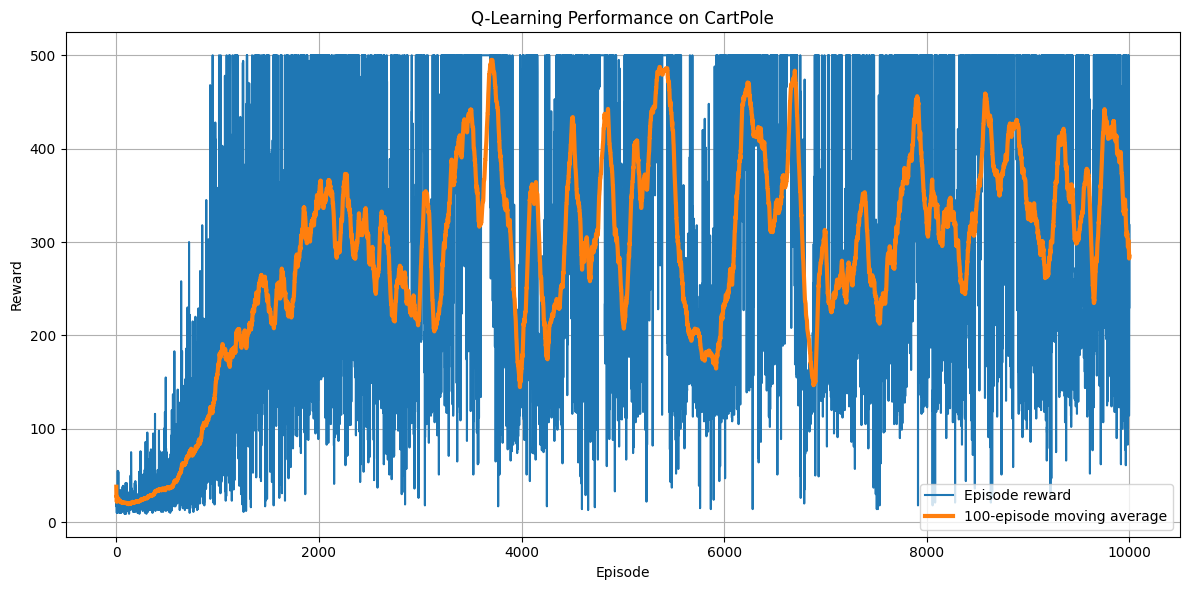

Test Episode 1: Total Reward = 349.0
Test Episode 2: Total Reward = 500.0
Test Episode 3: Total Reward = 500.0
Test Episode 4: Total Reward = 172.0
Test Episode 5: Total Reward = 500.0


In [ ]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque


# --- Parameters ---
NUM_BINS = (12, 12, 24, 24) # Binning resolution for each state dimension
NUM_EPISODES = 10000
MAX_STEPS = 500
GAMMA = 0.99
ALPHA = 0.3
EPSILON = 1.0
EPSILON_DECAY = 0.999
EPSILON_MIN = 0.01

# --- Environment Setup ---
def create_env():
    return gym.make("CartPole-v1")

# --- State Discretization ---
def create_bins(env, num_bins):
    obs_space = env.observation_space
    bins = []
    for i in range(len(obs_space.low)):
        low = obs_space.low[i]
        high = obs_space.high[i]

        # clip range for stability
        if i == 1:
            low, high = -3.0, 3.0
        elif i == 3:
            low, high = -3.5, 3.5

        bins.append(np.linspace(low, high, num_bins[i] - 1))
    return bins

def discretize(obs, bins):
    state = []
    for i, val in enumerate(obs):
        state.append(np.digitize(val, bins[i]))
    return tuple(state)

# --- Q-Table Initialization ---
def initialize_q_table(num_bins, num_actions):
    return np.zeros(shape=num_bins + (num_actions,))

# --- Epsilon-Greedy Policy ---
def choose_action(q_table, state, epsilon, num_actions):
    if random.uniform(0, 1) < epsilon:
        return random.randint(0, num_actions - 1)
    else:
        return np.argmax(q_table[state])

# --- Q-Update Rule ---
def update_q(q_table, state, action, reward, next_state, alpha, gamma):
    best_next = np.max(q_table[next_state])
    q_table[state][action] += alpha * (reward + gamma * best_next - q_table[state][action])

# --- Plotting Function ---
def plot_rewards(episode_rewards, window=100):
    smoothed = []
    for i in range(len(episode_rewards)):
        start = max(0, i - window + 1)
        avg = np.mean(episode_rewards[start:i+1])
        smoothed.append(avg)

    plt.figure(figsize=(12, 6))
    plt.plot(episode_rewards, label="Episode reward")
    plt.plot(smoothed, label=f"{window}-episode moving average", linewidth=3)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("Q-Learning Performance on CartPole")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

# --- Training Loop ---
def train(env, bins, num_episodes, max_steps):
    q_table = initialize_q_table(tuple(len(b) + 1 for b in bins), env.action_space.n)
    episode_rewards = []
    epsilon = EPSILON

    for episode in range(num_episodes):
        obs, _ = env.reset()
        state = discretize(obs, bins)
        total_reward = 0

        for _ in range(max_steps):
            action = choose_action(q_table, state, epsilon, env.action_space.n)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretize(next_obs, bins)

            update_q(q_table, state, action, reward, next_state, ALPHA, GAMMA)

            state = next_state
            total_reward += reward

            if done:
                break

        episode_rewards.append(total_reward)
        #epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
        if episode < num_episodes * 0.75:
            epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
        else:
            epsilon = 0.05  # small but non-zero to maintain exploration

        if (episode + 1) % 100 == 0:
            print(f"Episode {episode + 1}: Total reward = {total_reward}, Epsilon = {epsilon:.3f}")
    
    plot_rewards(episode_rewards)
    return q_table

# --- Evaluation ---
def evaluate(env, q_table, bins, episodes=10, render=False):
    for ep in range(episodes):
        obs, _ = env.reset()
        state = discretize(obs, bins)
        total_reward = 0

        for _ in range(MAX_STEPS):
            if render:
                env.render()
            action = np.argmax(q_table[state])
            obs, reward, terminated, truncated, _ = env.step(action)
            state = discretize(obs, bins)
            total_reward += reward
            if terminated or truncated:
                break
        print(f"Test Episode {ep + 1}: Total Reward = {total_reward}")

# --- Main ---
if __name__ == "__main__":
    env = create_env()
    bins = create_bins(env, NUM_BINS)
    q_table = train(env, bins, NUM_EPISODES, MAX_STEPS)
    evaluate(env, q_table, bins, episodes=5, render=True)
    env.close()


In [10]:

!pip install torch==2.0.1  

   ---------------------------------------- 0.0/172.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/172.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/172.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/172.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/172.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/172.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/172.3 MB ? eta -:--:--
   ---------------------------------------- 0.5/172.3 MB 541.6 kB/s eta 0:05:18
   ---------------------------------------- 0.5/172.3 MB 541.6 kB/s eta 0:05:18
   ---------------------------------------- 0.8/172.3 MB 486.4 kB/s eta 0:05:53
   ---------------------------------------- 0.8/172.3 MB 486.4 kB/s eta 0:05:53
   ---------------------------------------- 0.8/172.3 MB 486.4 kB/s eta 0:05:53
   ---------------------------------------- 1.0/172.3 MB 466.2 kB/s eta 0:06:08
   --------------------

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.17.0 requires torch==2.2.0, but you have torch 2.0.1 which is incompatible.

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\Shane\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random

# --- Hyperparameters ---
GAMMA = 0.99
LR = 1e-3
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995
EPISODES = 1000
MAX_STEPS = 500

# --- DQN Network ---
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.model(x)

# --- Action Selection ---
def choose_action(q_net, state, epsilon, action_dim):
    if random.random() < epsilon:
        return random.randint(0, action_dim - 1)
    else:
        with torch.no_grad():
            q_values = q_net(torch.tensor(state, dtype=torch.float32))
        return torch.argmax(q_values).item()

# --- Training Loop ---
def train(env, q_net, optimizer):
    episode_rewards = []
    epsilon = EPSILON_START

    for episode in range(EPISODES):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(MAX_STEPS):
            action = choose_action(q_net, state, epsilon, env.action_space.n)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            state_tensor = torch.tensor(state, dtype=torch.float32)
            next_state_tensor = torch.tensor(next_state, dtype=torch.float32)
            target = reward
            if not done:
                with torch.no_grad():
                    target += GAMMA * torch.max(q_net(next_state_tensor))

            q_values = q_net(state_tensor)
            loss = (q_values[action] - target).pow(2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            state = next_state
            total_reward += reward

            if done:
                break

        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
        episode_rewards.append(total_reward)

        if (episode + 1) % 100 == 0:
            print(f"Episode {episode + 1}: Total reward = {total_reward}, Epsilon = {epsilon:.3f}")

    return episode_rewards

# --- Reward Plotting ---
def plot_rewards(rewards, window=100):
    smoothed = []
    for i in range(len(rewards)):
        start = max(0, i - window + 1)
        smoothed.append(np.mean(rewards[start:i+1]))

    plt.figure(figsize=(12,6))
    plt.plot(rewards, label="Episode reward")
    plt.plot(smoothed, label=f"{window}-episode moving average", linewidth=3)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("DQN Performance on CartPole")
    plt.legend()
    plt.grid()
    plt.show()

# --- Main ---
if __name__ == "__main__":
    env = gym.make("CartPole-v1")
    input_dim = env.observation_space.shape[0]
    output_dim = env.action_space.n

    q_net = DQN(input_dim, output_dim)
    optimizer = optim.Adam(q_net.parameters(), lr=LR)

    rewards = train(env, q_net, optimizer)
    plot_rewards(rewards)


ImportError: cannot import name 'BlackHoleVariable' from 'torch._dynamo.variables.misc' (C:\Users\Shane\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torch\_dynamo\variables\misc.py)

# Classical Policy Gradients

Episode 100: Total reward = 32.0
Episode 200: Total reward = 52.0
Episode 300: Total reward = 105.0
Episode 400: Total reward = 33.0
Episode 500: Total reward = 500.0
Episode 600: Total reward = 360.0
Episode 700: Total reward = 500.0
Episode 800: Total reward = 433.0
Episode 900: Total reward = 500.0
Episode 1000: Total reward = 500.0
Episode 1100: Total reward = 500.0
Episode 1200: Total reward = 206.0
Episode 1300: Total reward = 31.0
Episode 1400: Total reward = 500.0
Episode 1500: Total reward = 500.0
Episode 1600: Total reward = 500.0
Episode 1700: Total reward = 500.0
Episode 1800: Total reward = 500.0
Episode 1900: Total reward = 500.0
Episode 2000: Total reward = 500.0
Episode 2100: Total reward = 500.0
Episode 2200: Total reward = 500.0
Episode 2300: Total reward = 220.0
Episode 2400: Total reward = 500.0
Episode 2500: Total reward = 500.0
Episode 2600: Total reward = 500.0
Episode 2700: Total reward = 500.0
Episode 2800: Total reward = 500.0
Episode 2900: Total reward = 500.

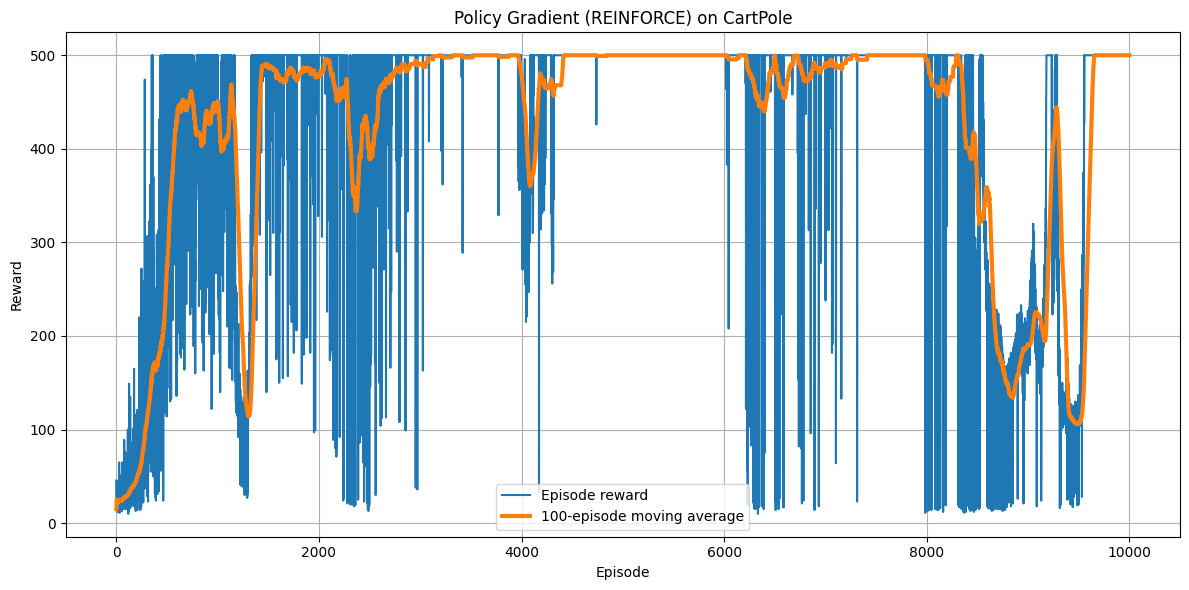

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

class PolicyNetwork(nn.Module):
    def __init__(self, obs_dim, hidden_size, act_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, act_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.model(x)

def compute_returns(rewards, gamma=0.99):
    G = 0
    returns = []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return returns

def train(env, policy, optimizer, episodes=10000, max_steps=500, gamma=0.99):
    episode_rewards = []

    for episode in range(episodes):
        obs, _ = env.reset()
        obs = torch.tensor(obs, dtype=torch.float32)
        log_probs = []
        rewards = []
        total_reward = 0

        for _ in range(max_steps):
            probs = policy(obs)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()
            log_probs.append(dist.log_prob(action))

            next_obs, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            rewards.append(reward)
            total_reward += reward

            obs = torch.tensor(next_obs, dtype=torch.float32)

            if done:
                break

        returns = compute_returns(rewards, gamma)
        returns = torch.tensor(returns, dtype=torch.float32)
        #returns = (returns - returns.mean()) / (returns.std() + 1e-8)  # normalize
        returns = (returns - returns.min()) / (returns.max() - returns.min() + 1e-8)

        #loss = -torch.sum(torch.stack(log_probs) * returns)
        entropy = -torch.sum(probs * torch.log(probs + 1e-8))
        loss = -torch.sum(torch.stack(log_probs) * returns) - 0.01 * entropy

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        episode_rewards.append(total_reward)

        if (episode + 1) % 100 == 0:
            print(f"Episode {episode + 1}: Total reward = {total_reward}")

    return episode_rewards

def plot_rewards(rewards, window=100):
    smoothed = []
    for i in range(len(rewards)):
        start = max(0, i - window + 1)
        avg = np.mean(rewards[start:i+1])
        smoothed.append(avg)

    plt.figure(figsize=(12, 6))
    plt.plot(rewards, label="Episode reward")
    plt.plot(smoothed, label=f"{window}-episode moving average", linewidth=3)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("Policy Gradient (REINFORCE) on CartPole")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    env = gym.make("CartPole-v1")
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    policy = PolicyNetwork(obs_dim, hidden_size=128, act_dim=act_dim)
    optimizer = optim.Adam(policy.parameters(), lr=0.001)

    rewards = train(env, policy, optimizer)
    plot_rewards(rewards)
